# CSE2530 Computational Intelligence
## Assignment 2: Artificial Neural Networks

<div style="background-color:#be3e3a">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           X          |
|------------|----------------------|
| Daniel Kolev  |        6160255       |
| Zain Qureshi  |        6143555       |
| Deyan Papazov  |        6191150       |
| Student D  |        XXXXXXX       |

</div>

#### Imports

In [1]:
# You may only use numpy to implement your neural network
# You are not allowed to use scikit-learn, other than for Section 1.6.
# You are also not allowed to use Pytorch, Tensorflow, and similar machine learning frameworks.
# You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.

# Put all of your imports in this code block
import numpy as np
import matplotlib.pyplot as plt

#### Loading the data

In [2]:
features = np.genfromtxt("../data/features.txt", delimiter=",")
targets = np.genfromtxt("../data/targets.txt", delimiter=",")
unknown = np.genfromtxt("../data/unknown.txt", delimiter=",")

## 1 Questions
### 1.2 Architecture
#### Question 1:

First we will implement our perceptron and will include all the necessary methods that it needs:
 - the constructor which takes the amount of weights we want, which is the amount of features we have. The default one will be 10, since our dataset contains 10 features, but we use the parameter so that we can pass 2 for the AND, OR, XOR cases

In [3]:
# Put your code for Question 1 here
class Perceptron:
    
    # Constructor for creating our perceptron
    def __init__(self, sizet = 10, rate = 0.01):
        self.weights = np.random.rand((sizet))
        self.bias = np.random.rand()
        self.alpha = rate

    # Function for applying the step function
    def step(self, z):
        return np.where(z >= 0, 1, 0)
    
    # Function for predicting the label
    def predict(self,input_features):
        return self.step(np.dot(self.weights, input_features.T) + self.bias)
    
    # Function for calculating the loss
    def loss(self, prediction, label):
        return label - prediction
    
    # Function for training the perceptron for a given number of epochs and returning the loss per epoch
    def train(self, train_data, train_labels, epochs = 100):
        loss_per_epoch = []
        for i in range(epochs):
            curr_loss = 0
            for (row,actual) in zip(train_data,train_labels):
                z = self.predict(row)
                loss = self.loss(z, actual)
                curr_loss += abs(loss)
                self.weights = [w + row[j] * self.alpha * loss for j,w in enumerate(self.weights)]
                self.bias = self.bias + self.alpha * loss
            print(f"Loss for epoch {i} is {curr_loss}")
            loss_per_epoch.append(curr_loss)

        return loss_per_epoch

In [4]:
# Function for computing the accuracy based on predictions and labels
def accuracy(predictions, labels):
    return np.mean(np.where(predictions == labels, 1, 0)) * 100

### OR Gate
We will now create our Perceptron for an OR Gate. We create the correct inputs and outputs and call the Perceptron with size 2 since we have 2 features per measurements - namely x and y. Then we cal the train function in order to get the loss list and therefore be able to plot the losses for each epoch.

Loss for epoch 0 is 1
Loss for epoch 1 is 1
Loss for epoch 2 is 1
Loss for epoch 3 is 1
Loss for epoch 4 is 1
Loss for epoch 5 is 1
Loss for epoch 6 is 0
Loss for epoch 7 is 0
Loss for epoch 8 is 0
Loss for epoch 9 is 0
Accuracy of Perceptron for OR gate:  100.0


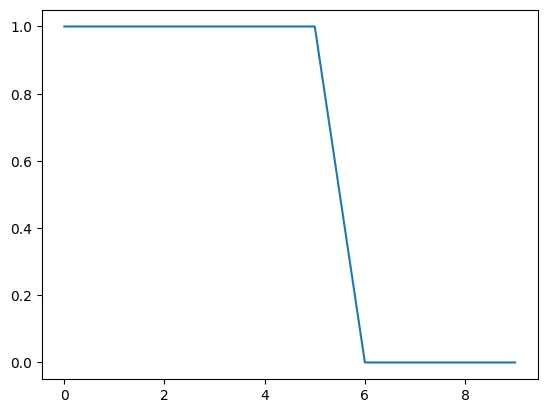

In [5]:
input_x = np.array([[0, 1], [0, 0], [1, 1], [1, 0]])

input_y_or = np.array([1, 0, 1, 1])
or_perceptron = Perceptron(sizet = 2, rate = 0.1)
or_loss_list = or_perceptron.train(input_x, input_y_or, 10)  
print("Accuracy of Perceptron for OR gate: ", accuracy(or_perceptron.predict(input_x),input_y_or))
plt.plot(or_loss_list)
plt.show()



## AND Gate

We will do the same for the AND Gate

Loss for epoch 0 is 2
Loss for epoch 1 is 2
Loss for epoch 2 is 1
Loss for epoch 3 is 1
Loss for epoch 4 is 1
Loss for epoch 5 is 0
Loss for epoch 6 is 0
Loss for epoch 7 is 0
Loss for epoch 8 is 0
Loss for epoch 9 is 0
Accuracy of Perceptron for AND gate:  100.0


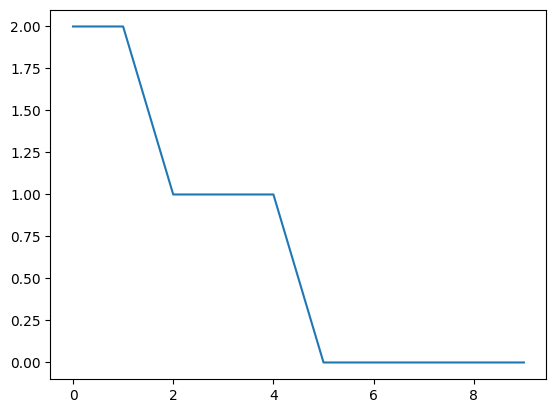

In [6]:
input_y_and = np.array([0, 0, 1, 0])
and_perceptron = Perceptron(sizet = 2, rate = 0.1)
and_loss_list = and_perceptron.train(input_x, input_y_and, 10)  
print("Accuracy of Perceptron for AND gate: ", accuracy(and_perceptron.predict(input_x),input_y_and))
plt.plot(and_loss_list)
plt.show()


## XOR Gate

And the same for the XOR Gate. For the XOR Gate we can see that the loss never goes to 0, meaning that we can not train our model to achieve 100% accuracy for XOR since our model with 1 perceptron is not able to learn XOR

Loss for epoch 0 is 2
Loss for epoch 1 is 4
Loss for epoch 2 is 4
Loss for epoch 3 is 4
Loss for epoch 4 is 4
Loss for epoch 5 is 4
Loss for epoch 6 is 4
Loss for epoch 7 is 4
Loss for epoch 8 is 4
Loss for epoch 9 is 4
Loss for epoch 10 is 4
Loss for epoch 11 is 4
Loss for epoch 12 is 4
Loss for epoch 13 is 4
Loss for epoch 14 is 4
Loss for epoch 15 is 4
Loss for epoch 16 is 4
Loss for epoch 17 is 4
Loss for epoch 18 is 4
Loss for epoch 19 is 4
Accuracy of Perceptron for XOR gate:  25.0


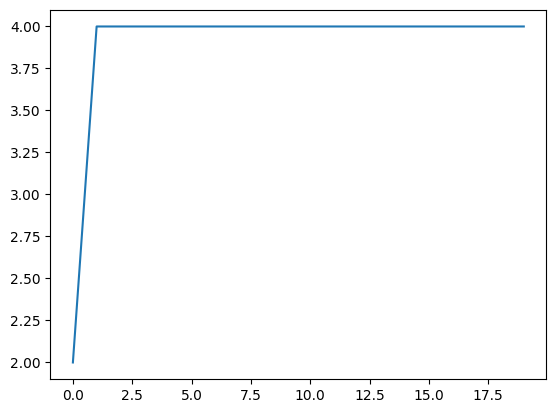

In [7]:
input_y_xor = np.array([1, 0, 0, 1])
xor_perceptron = Perceptron(sizet = 2, rate = 0.1)
xor_loss_list = xor_perceptron.train(input_x, input_y_xor, 20)
print("Accuracy of Perceptron for XOR gate: ", accuracy(xor_perceptron.predict(input_x),input_y_xor))
plt.plot(xor_loss_list)
plt.show()


<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 2

<div>

We are going to need a total of 10 input neurons since we have a total of 10 features by which our dataset is desigined. For one observation, each of its features goes to a single neuron which has its own weight and bias

</div>

#### Question 3

We need a total of 7 output neurons, one for each class, showing the probability of the data point belonging to this class


#### Question 4

We do not think there is a way of knowing exactly how many hidden layers we will need, but we can maybe start with 8, then move on to 16, 32 etc

#### Question 5

We need an activation function in order to introduce non-lineearity in our network, since data is usually not separable linearly. We must use a differentiable function since backpropagation needs every function to be differentiable or we can define what the derivative at the non-differentiable points will be. We can use Sigmoid (differentiable) or RELU (non-differentiable and define it for 0)

#### Question 6

<div style="background-color:#f1be3e">

_Write your answer here. You can include images using the syntax !.[title].(filepath), removing decimal points therein._

</div>

### 1.3 Training

When coding a neural network from scratch, it helps to think of a layer as an individual component that can be easily combined with other layers. To help you create a modular implementation of a neural network, we provide you with a template for the implementation along with some explanations.

**Note that using the template below is not mandatory. You may choose to modify this template or implement your own version of the neural network altogether. If the latter, please remove our template from the notebook and ensure that it instead includes a complete, fully functional implementation of your own.**

**Linear (fully connected) layer**

A linear or fully connected layer maps the input data to an output by performing a linear transformation, where each input neuron is connected to every output neuron. The forward pass of a linear layer is computed as $y = wx + b$, where $w$ and $b$ are trainable parameters. The gradients of the loss with respect to $w$ and $b$ are defined using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial w}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial w}, \quad \frac{\partial \mathcal{L}}{\partial b}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial b}, $$

where $\frac{\partial \mathcal{L}}{\partial y}$ is the upstream gradient i.e., the gradient flowing from deeper layers into the current layer, and the other two terms are the local gradients:

$$
\frac{\partial y}{\partial w}=x, \quad \frac{\partial y}{\partial b}=1.
$$

Since $x$ is needed to compute the gradients, we can store (cache) its value during the forward pass. Finally, we need to return a downstream gradient so that more shallow layers can use it as their upstream gradient. The downstream gradient of a layer is simply its upstream gradient multiplied by the local gradient of its ouput with respect to its input:

$$
\frac{\partial \mathcal{L}}{\partial x}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial x}
$$

**Note.** Be aware of how you multiply the arrays, it might be useful to print the shapes of each array and to think about the desired shape of the output.  

In [31]:
class Linear:
    def __init__(self, in_features, out_features, init_type="xavier"):
        """ Randomly initialize the weights and biases.
    
        Args:
            in_features: number of input features.
            out_features: number of output features.
        """
        # We will use Xavier initialization for the weights and initialize the bias to zero
        if init_type == "xavier":
            self.weight = np.random.randn(in_features, out_features) * np.sqrt(1.0 / in_features)
        elif init_type == "he":
            self.weight = np.random.randn(in_features, out_features) * np.sqrt(2.0 / in_features)
        elif init_type == "uniform":
            self.weight = np.random.uniform(-0.1, 0.1, (in_features, out_features)) 

        self.bias = np.zeros(out_features)

        self.cache = None
        # For storing the gradients w.r.t. the weight and the bias
        self.weight_grad = None
        self.bias_grad = None

    def forward(self, x):
        """ Perform the forward pass of a linear layer. 
        Store (cache) the input so it can be used in the backward pass.

        Args:
            x: input of a linear layer.

        Returns: 
            y: output of a linear layer. 
        """
        self.cache = x
        return np.dot(x, self.weight) + self.bias
        pass
    
    def backward(self, dupstream):
        """ Perform the backward pass of a linear layer.  

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        self.weight_grad = np.dot(self.cache.T, dupstream) # dot product of the transpose of the cached input and the upstream gradient
        self.bias_grad = np.sum(dupstream, axis=0) # dot product of dupstream and a vector of ones of the same size
        return dupstream.dot(self.weight.T)
    pass

**Activation functions**

You also need to implement an activation function suitable for the task at hand.

Think about how to perform the backward pass i.e., what is the local gradient and what the downstream gradient should be. Do not forget to take the upstream gradient into account.

We will create two classes for the Activation Functions
- ActivationSigmoid, which is responsible for the hidden layers
- ActivationSoftmax, which will be reponsible for being the Activation Function for the output layer, since we have to output probabilities

In [9]:
class ActivationSigmoid:
    def __init__(self):
        self.cache = None
    def forward(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. 

        Returns:
            y: output of the activation function.
        """
       
        output = 1 / (1 + np.exp(-x)) # Sigmoid activation function
        self.cache = output
        return output
    
    def backward(self, dupstream): 
        """ Perform a backward pass of the activation function. 
        Make sure you do not modify the original dupstream.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """

        return dupstream * self.cache * (1 - self.cache) # derivative of sigmoid function is sigmoid(x) * (1 - sigmoid(x))
        
        pass

In [ ]:
class ActivationRelu:
    def __init__(self):
        self.cache = None
    def forward(self, x):
        """ Perform a forward pass of the activation function.
        Store the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. 

        Returns:
            y: output of the activation function.
        """
        output = np.maximum(0, x)
        self.cache = output
        return output
    
    def backward(self, dupstream): 
        """ Perform a backward pass of the activation function. 

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """

        return dupstream * np.where(self.cache > 0, 1, 0) # derivative of ReLU function is 1 for x > 0 and 0 otherwise
        
        pass

In [11]:
class ActivationSoftmax:
    def __init__(self):
        self.cache = None
    def forward(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. 

        Returns:
            y: output of the activation function.
        """
        output = np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True) # Softmax activation function
        self.cache = output
        return output
    
    def backward(self, dupstream):
        """ Perform a backward pass of the activation function. 

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        s = self.cache
        dot = np.sum(dupstream * s, axis=1, keepdims=True)
        dx = s * (dupstream - dot)
        return dx

**Network** 

Now that you have implemented a `Linear` layer and an activation function, you can combine them in different ways and have the `Network` class perform forward and backward passes through all layer of the network in the specified order.

Additionally, you should make the `Network` class update all the trainable parameters of the network in `optimizer_step`.

In [12]:
class Network:
    def __init__(self, layers, output_layer):
        self.layers = layers
        self.output_layer = output_layer
    def forward(self, x):
        """ Perform a forward pass over the entire network.

        Args:
            x: input data. 

        Returns:
            y: predictions.
        """
        for layer in self.layers:
            x = layer.forward(x)
        return self.output_layer.forward(x)
        
    def backward(self, dupstream):
        """ Perform a backward pass over the entire network.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        dupstream = self.output_layer.backward(dupstream) # Here we receive the gradient of the loss
        for layer in reversed(self.layers):
            dupstream = layer.backward(dupstream)
        return dupstream
    
    def optimizer_step(self, lr):
        """ Update the weight and bias parameters of each layer.

        Args:
            lr: learning rate.
        """
        for layer in self.layers:
            if isinstance(layer, Linear):
                layer.weight -= lr * layer.weight_grad
                layer.bias -= lr * layer.bias_grad
        pass

**Loss function**

You also need to implement a loss function that will measure
 how well your neural network performs at the task.
Since we are using Softmax it is suitable to use the Cross Entroy. The reason is because we are outputting probabilities for each class which Cross Entropy takes into account

In [13]:
# Cross Entropy Loss Function
def Loss(y_true, y_pred):
    """ Computes the value of the loss function and its gradient.  

    Args:
        y_true: ground truth labels.
        y_pred: predicted labels.

    Returns:
        loss: value of the loss. 
        grad: gradient of loss with respect to the predictions. 
    """
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon) # To avoid log(0) which is undefined
    loss = -np.mean(np.sum(y_true * np.log(y_pred), axis = 1)) # Cross entropy loss
    grad = -(y_true / y_pred) / y_true.shape[0] # Gradient of the loss with respect to the predictions
    return loss, grad

**Training loop**

Finally, define a training loop in which for each optimizer step you:

1. Obtain the predictions by performing a forward pass of the network;

2. Compute the loss and its gradient by comparing the predictions with the ground truth according to the selected criterion;

3. Perform a backward pass of the network;

4. Update all parameters of the network i.e, take an optimizer step.

In [38]:
def compute_accuracy(predictions, labels):
    pred_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(labels, axis=1)
    accuracy = np.mean(pred_labels == true_labels)
    return accuracy

def train_with_statistics(net, inputs, labels, criterion, lr, epochs = 1000):
    """Trains the neural network.

    Args:
        net: network or model. 
        inputs: input data.
        labels: labels. 
        criterion: loss function.
        lr: learning rate.

    Returns:
        losses: a list containing the loss at every optimizer step. 
        accuracies: a list containing the accuracy at every optimizer step. 
    """
    losses = []
    accuracies = []
    for i in range(epochs):
        print(f"Starting Epoch {i}:")

        # Do the forward pass and get the predictions for the current inputs
        predictions = net.forward(inputs)

        # Get the loss and gradient of the loss with respect to the predictions
        loss, grad = criterion(labels, predictions)

        # Do the backward pass
        net.backward(grad)

        # Update the weights and biases of the network using the optimizer step
        net.optimizer_step(lr)

        # Append the loss to the list of losses
        losses.append(loss)

        # Calculate accuracy
        accuracy = compute_accuracy(predictions, labels)
        print(f"Loss: {loss}, Accuracy: {accuracy * 100:.2f}%")
        accuracies.append(accuracy)
    return losses, accuracies

## Training our Network

Before training our model we will look into the data that we have and see if we need to do some preprocessing

In [15]:
print("Features shape: ", features.shape)
print("Targets shape: ", targets.shape)
print("Minimal class: ", np.min(targets))
print("Maximal class: ", np.max(targets))
print("Number of classes: ", np.max(targets) - np.min(targets) + 1)

Features shape:  (7854, 10)
Targets shape:  (7854,)
Minimal class:  1.0
Maximal class:  7.0
Number of classes:  7.0


Based on those statistics we can see that we have 7854 samples with 10 features each as specified in the assignment. The lowest label is 1 and not 0, which we need to take into account. Another thing we should also keep in mind is that the targets array is 1 dimensional, which could be problematic for our matrix multiplications so we should reshape it

In [16]:
targets_zero_indexed = targets.astype(int) - 1 # Convert labels from [1..7] → [0..6] so that we can use them as indices for one-hot encoding
targets_onehot = np.zeros((targets.shape[0], 7)) # We have 7 classes, so we create a zero matrix of shape (number of samples, number of classes)
targets_onehot[np.arange(targets.shape[0]), targets_zero_indexed] = 1 # np arrange gives equally spaced values within a given interval, in this case we create an array of indices from 0 to number of samples - 1, and we use the zero indexed targets as the column indices to set the corresponding positions in the one-hot matrix to 1
print("New shape of targets_onehot: ", targets_onehot.shape)
print(targets_onehot[:5])

New shape of targets_onehot:  (7854, 7)
[[0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]]


Now our input targets are correctly converted to one_hot vectors, since our loss functions expects them to be in this form so that it can do matrix multiplication.

We will now decide how we are going to split our data such that there is an unbiased estimate of performance. Before wondering how we should split it, its important to see the distribution of classes, since our training data might be heavily imbalanced and we need to take that into consideration when choosing the training set. We want a balanced dataset, because it prevents our Neural Network from becoming biased towards particular classes, which would decrease our accuracy

Class distribution:  [   0 1119 1117 1131 1111 1127 1126 1123]


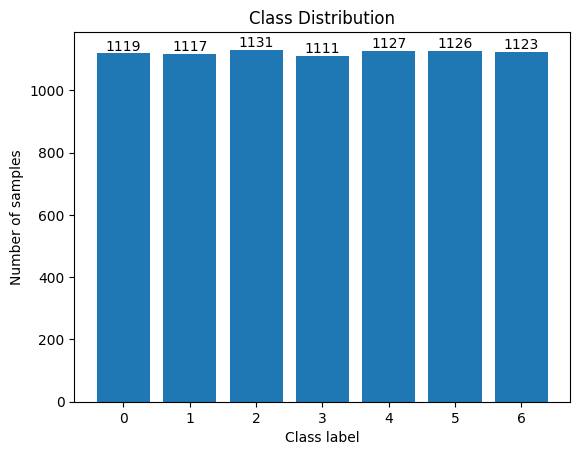

In [17]:
print("Class distribution: ", np.bincount(targets.astype(int)))

# Plotted the results using generative AI
counts = np.bincount(targets_zero_indexed)


classes = np.arange(len(counts))

plt.figure()
plt.bar(classes, counts)

plt.title("Class Distribution")
plt.xlabel("Class label")
plt.ylabel("Number of samples")

plt.xticks(classes)  # ensures labels show 0,1,2,...,6

# how exact numbers above bars
for i, count in enumerate(counts):
    plt.text(i, count + 10, str(count), ha='center')

plt.show()

Based on this we can clearly see that the class distribution is balanced, with each class containing approximately the same number of samples. This indicates that the dataset does not suffer from class imabalance, which is good.

To ensure an unbiased estimate of the model’s performance on unseen data, we will split it into three subsets: training (70%), validation (15%), and test (15%). We will perform random shuffling using a randomly permuted index array, which we will then apply to both the feature matrix and the target labels. This ensures that samples are randomly distributed across the subsets while preserving the correspondence between features and labels.

In [ ]:
# Splitting our data such that there is an unbiased estimate of the performance of our model on unseen data
num_samples = features.shape[0]

indices = np.arange(num_samples)
np.random.seed(42)  # Set a random seed for reproducibility
np.random.shuffle(indices)
# Apply shuffle to features and targets
features_shuffled = features[indices]
targets_shuffled = targets_onehot[indices]

train_end = int(0.7 * num_samples)
val_end = int(0.85 * num_samples)

X_train = features_shuffled[:train_end]
y_train = targets_shuffled[:train_end]

X_val = features_shuffled[train_end:val_end]
y_val = targets_shuffled[train_end:val_end]

X_test = features_shuffled[val_end:]
y_test = targets_shuffled[val_end:]
print("Train features shape:", X_train.shape)
print("Train targets shape:", y_train.shape)
print("Validation features shape:", X_val.shape)
print("Validation targets sh.ape:", y_val.shape)
print("Test features shape:", X_test.shape)
print("Test targets shape:", y_test.shape)

Train features shape: (5497, 10)
Train targets shape: (5497, 7)
Validation features shape: (1178, 10)
Validation targets shape: (1178, 7)
Test features shape: (1179, 10)
Test targets shape: (1179, 7)


Class distribution:  [   0 1119 1117 1131 1111 1127 1126 1123]


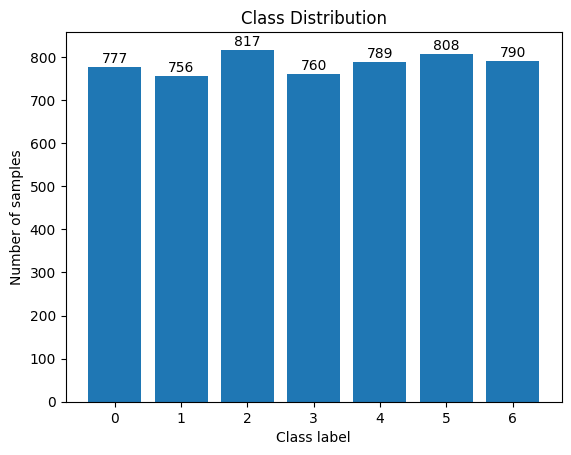

In [19]:
print("Class distribution: ", np.bincount(targets.astype(int)))

# Plotted the results using generative AI
counts = np.bincount(y_train.argmax(axis=1))  # Get class counts from one-hot encoded labels


classes = np.arange(len(counts))

plt.figure()
plt.bar(classes, counts)

plt.title("Class Distribution")
plt.xlabel("Class label")
plt.ylabel("Number of samples")

plt.xticks(classes)  # ensures labels show 0,1,2,...,6

# how exact numbers above bars
for i, count in enumerate(counts):
    plt.text(i, count + 10, str(count), ha='center')

plt.show()

We will now finally train our network with our balanced dataset. We will use a fixed learning rate of 0.01 and 10 000 epochs to visualize our model and then we will validate it

Starting Epoch 0:
Loss: 1.9949917671091515, Accuracy: 14.81%
Starting Epoch 1:
Loss: 1.9752240114443775, Accuracy: 15.06%
Starting Epoch 2:
Loss: 1.9588541132612092, Accuracy: 15.55%
Starting Epoch 3:
Loss: 1.9450073954586575, Accuracy: 16.12%
Starting Epoch 4:
Loss: 1.932997848281741, Accuracy: 16.72%
Starting Epoch 5:
Loss: 1.9224243140783568, Accuracy: 17.39%
Starting Epoch 6:
Loss: 1.9130298615914825, Accuracy: 17.85%
Starting Epoch 7:
Loss: 1.904545426315876, Accuracy: 18.46%
Starting Epoch 8:
Loss: 1.8967898042919071, Accuracy: 19.08%
Starting Epoch 9:
Loss: 1.8896489718108418, Accuracy: 19.96%
Starting Epoch 10:
Loss: 1.8830415444663082, Accuracy: 20.76%
Starting Epoch 11:
Loss: 1.8768062427235843, Accuracy: 21.32%
Starting Epoch 12:
Loss: 1.8709603051466028, Accuracy: 21.83%
Starting Epoch 13:
Loss: 1.8654668921771296, Accuracy: 22.59%
Starting Epoch 14:
Loss: 1.8602411074436982, Accuracy: 22.94%
Starting Epoch 15:
Loss: 1.8552406748252817, Accuracy: 23.38%
Starting Epoch 16:
L

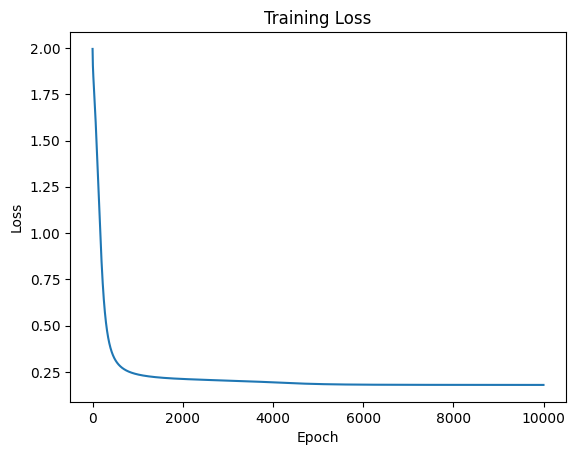

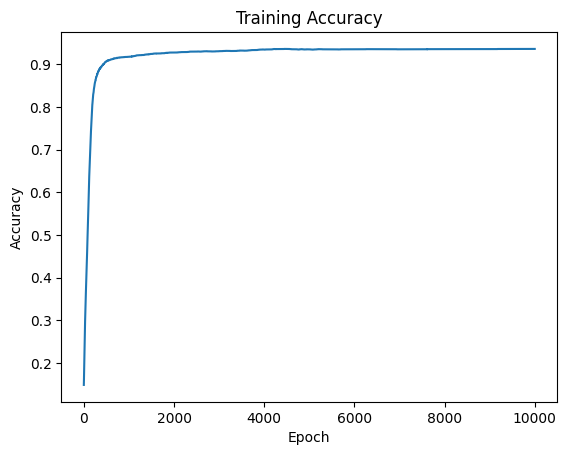

In [60]:
curr_network = Network(
    layers=[Linear(10, 10), ActivationRelu(), Linear(10, 7)],
    output_layer=ActivationSoftmax()
)

# Train
losses, accuracies = train_with_statistics(
    curr_network,
    X_train,
    y_train,
    Loss,
    lr=0.1,
    epochs=10000
)

# Plotted results using generative AI
print("Final Accuracy: ", accuracies[-1])

# Plot loss
plt.figure()
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Plot accuracy
plt.figure()
plt.plot(accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


Based on the plots above we can see that the loss is decreasing steadily since our network is updating its parameters and adapting to our data. The same goes for the Accuracy, which is increasing and peaking at around 91%

We will now use the validation set to find the suitable hyperparameters or more specifically, learning rate and number of epochs

In [21]:
def evaluate(net, inputs, labels, criterion):
    predictions = net.forward(inputs)
    accuracy = compute_accuracy(predictions, labels)
    loss, _ = criterion(labels, predictions)
    return loss, accuracy

Early stopping triggered at epoch 478 with validation loss: 0.3752
LR: 0.1 Optimal Epoch: 478 Validation accuracy: 93.04%


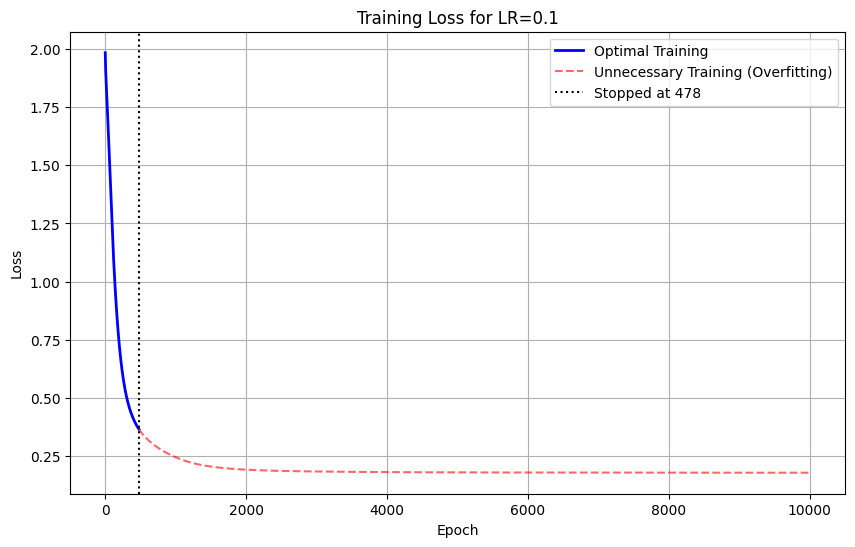

Early stopping triggered at epoch 1805 with validation loss: 0.7501
LR: 0.01 Optimal Epoch: 1805 Validation accuracy: 91.51%
Early stopping triggered at epoch 21 with validation loss: 1.9829
LR: 0.001 Optimal Epoch: 21 Validation accuracy: 58.23%

--- Final Results ---
Best learning rate: 0.1
Best validation accuracy: 93.04%
Best optimal number of epochs: 478


In [72]:
def train_one_epoch(net, X_train, y_train, criterion, lr):
    predictions = net.forward(X_train)
    loss, grad = criterion(y_train, predictions)
    net.backward(grad)
    net.optimizer_step(lr)
    acc = compute_accuracy(predictions, y_train)
    return loss, acc


def train_with_early_stopping(net, X_train, y_train, X_val, y_val, criterion, lr, epochs=10000, patience=20, min_delta=0.001):
    best_val_loss = float("inf")
    epochs_without_improvement = 0
    training_losses = [] 
    stopping_epoch = None # NEW: Keep track of when we should have stopped

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(net, X_train, y_train, criterion, lr)
        training_losses.append(train_loss) 

        val_predictions = net.forward(X_val)
        val_loss, _ = criterion(y_val, val_predictions)

        # Only check for improvements if we haven't hit the stopping point yet
        if stopping_epoch is None:
            if val_loss < (best_val_loss - min_delta): 
                best_val_loss = val_loss
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered at epoch {epoch + 1} with validation loss: {val_loss:.4f}")
                stopping_epoch = epoch + 1 
                # Notice we removed the 'return' here! It will keep training now.

    # If it never triggered, the stopping point is the very end
    if stopping_epoch is None:
        stopping_epoch = epochs

    # Return all three pieces of information
    return epochs, training_losses, stopping_epoch

learning_rates = [0.1, 0.01, 0.001]

best_val_acc = 0
best_lr = None
best_network = None
best_epoch_overall = None 

for lr in learning_rates:
    network = Network(
        layers=[Linear(10, 10), ActivationRelu(), Linear(10, 7)],
        output_layer=ActivationSoftmax()
    )
    
    current_epochs, history_losses, stop_epoch = train_with_early_stopping(
        network, X_train, y_train, X_val, y_val, Loss, lr=lr, epochs=10000, min_delta=0.01, patience=20
    )
    
    val_loss, val_acc = evaluate(network, X_val, y_val, Loss)
    print("LR:", lr, "Optimal Epoch:", stop_epoch, "Validation accuracy:", f"{val_acc * 100 :.2f}%")

    if lr == 0.1:
        plt.figure(figsize=(10, 6))
        
        plt.plot(range(stop_epoch), history_losses[:stop_epoch], 
                 label="Optimal Training", color='blue', linewidth=2)
        
        if stop_epoch < current_epochs:
            plt.plot(range(stop_epoch - 1, current_epochs), history_losses[stop_epoch - 1:], 
                     label="Unnecessary Training (Overfitting)", color='red', linestyle='--', alpha=0.6)
            
            plt.axvline(x=stop_epoch, color='black', linestyle=':', label=f'Stopped at {stop_epoch}')

        plt.title(f"Training Loss for LR={lr}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        plt.show()  
    
    # We keep the best-tracking logic outside the 'if' so it still checks all 3 rates!
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_lr = lr
        best_network = network
        best_epoch_overall = stop_epoch

print("\n--- Final Results ---")
print("Best learning rate:", best_lr)
print("Best validation accuracy:", f"{best_val_acc * 100 :.2f}%")
print("Best optimal number of epochs:", best_epoch_overall)

In [27]:
print("Best learning rate:", best_lr, "with validation accuracy:", f"{best_val_acc * 100 :.2f}%", "and number of epochs:", best_epoch_overall)


Best learning rate: 0.01 with validation accuracy: 91.94% and number of epochs: 10000


In [30]:
train_loss, train_acc = evaluate(best_network, X_train, y_train, Loss)
val_loss, val_acc = evaluate(best_network, X_val, y_val, Loss)
test_loss, test_acc = evaluate(best_network, X_test, y_test, Loss)

print("Training accuracy:", f"{train_acc * 100 :.2f}%")
print("Training loss:", train_loss)
print("-------------------------")
print("Validation accuracy:", f"{val_acc * 100 :.2f}%")
print("Validation loss:", val_loss)
print("-------------------------")
print("Test Accuracy:", f"{test_acc * 100 :.2f}%")
print("Test loss:", test_loss)

Training accuracy: 93.56%
Training loss: 0.18006072460979045
-------------------------
Validation accuracy: 92.78%
Validation loss: 0.20367868817315776
-------------------------
Test Accuracy: 93.04%
Test loss: 0.21030473683033185


#### Question 7

<div>

To obtain an unbiased estimate of the model's performance, we divide our dataset into three disjoint subsets - a training set(70%), a validation set (15%) and a test set(15%). The training set is used to train the network and learn the correct parameters, the validation set is used to tune hyperparameters such as the leearning rate and number of epochs, and the test set for evaluating the final model performance.

Before splitting, we randomly shuffle the dataset using a ranodmly permuted index array. This shuffled index array is applied to both feature smatrix and the target labels. Random shuffling ensures that samples are distributed randomly across the trainingmvalidation and test sets preventing any ordering bias that could affect model evaluation.

Since the original dataset is balanced, with each class containing approximately the same number of samples, random shuffling preserves similar class proportions across all subsets. This ensures that the model is trained and evaluated on representative data, preventing bias toward any specific class and enabling reliable performance estimation.

To ensure reproducibility, the random number generator can be initialized with a fixed seed before shuffling. This guarantees that the same data split is produced every time the experiment is run, allowing consistent and reproducible results.

</div>

#### Question 8

<div>
Classification accuracy measures the proportion of correctly classified samples. It is computed by comparing the predicted class, obtained using the argmax of the Softmax output, with the true class label. Accuracy provides an interpretable measure of performance, as it directly reflects how often the network makes correct predictions. Since the dataset is balanced across all classes, accuracy is an appropriate and reliable metric, as it is not biased toward any particular class.

Cross-entropy loss measures the difference between the predicted probability distribution and the true class distribution. It evaluates how confident the model is in its predictions and provides a continuous measure of performance that is directly optimized during training through gradient descent. Monitoring the loss over time allows assessment of whether the model is learning effectively and converging.

Both loss and accuracy were plotted as functions of training epochs. The loss plot shows how the optimization process progresses, while the accuracy plot shows how the model’s predictive performance improves over time. The validation accuracy and loss provide an estimate of how well the model generalizes to unseen data and help detect overfitting.

</div>

#### Question 9

We have implemented the train_with_early_stopping function which stops early when the loss does not decrease more than 20 times consecutively. This is okay since we assume that if the loss has not decreased for 20 consecutive times then it will probably not decrease anymore and we can stop early. By doing this we ensure that we do not train the model excessively.By actively monitoring a validation set, early stopping halts the training at the exact point where the model's ability to generalize stops improving, preventing overfitting and saving computational time.

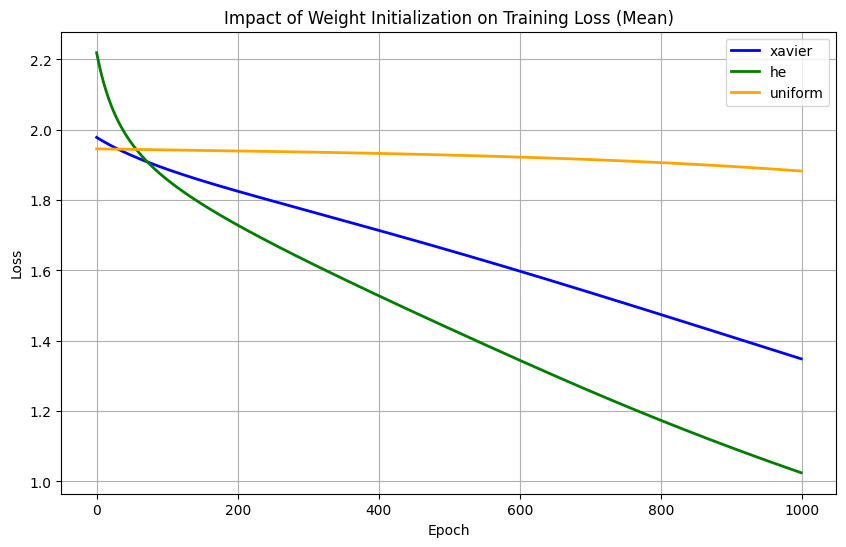

In [43]:
def train_without_statistics(net, inputs, labels, criterion, lr=0.01, epochs=10000):
    """Trains the neural network.

        Args:
            net: network or model. 
            inputs: input data.
            labels: labels. 
            criterion: loss function.
            lr: learning rate.

        Returns:
            losses: a list containing the loss at every optimizer step. 
            accuracies: a list containing the accuracy at every optimizer step. 
        """
    losses = []
    accuracies = []
    for i in range(epochs):
        # Do the forward pass and get the predictions for the current inputs
        predictions = net.forward(inputs)
        # Get the loss and gradient of the loss with respect to the predictions
        loss, grad = criterion(labels, predictions)
        # Do the backward pass
        net.backward(grad)
        # Update the weights and biases of the network using the optimizer step
        net.optimizer_step(lr)
        # Append the loss to the list of losses
        losses.append(loss)
        # Calculate accuracy
        accuracy = compute_accuracy(predictions, labels)
        accuracies.append(accuracy)
    return losses, accuracies
# Define the initialization types we want to test
init_types = ["xavier","he", "uniform"]
runs_per_init = 5
epochs = 1000 # We use less epochs here for testing purposes
lr = 0.01

results = {"xavier": [], "uniform": [], "he": []}

for init in init_types:
    for run in range(runs_per_init):
        net = Network(
            layers=[
                Linear(10, 10, init_type=init), 
                ActivationRelu(), 
                Linear(10, 7, init_type=init)
            ],
            output_layer=ActivationSoftmax()
        )
        
        losses, accuracies = train_without_statistics(net, X_train, y_train, Loss, lr=lr, epochs=epochs)
        
        # Store the loss curve for plotting
        results[init].append(losses)

# Plotting the results using generative AI
plt.figure(figsize=(10, 6))

# Map colors to make the loop cleaner
colors = {'xavier': 'blue', 'uniform': 'orange', 'he': 'green'}

for init in init_types:
    # Convert the list of runs into a 2D numpy array (shape: runs x epochs)
    losses_array = np.array(results[init])
    
    # Calculate mean and standard deviation across the 5 runs
    mean_losses = np.mean(losses_array, axis=0)
        
    epochs_range = range(epochs)
    
    # Plot the solid mean line
    plt.plot(epochs_range, mean_losses, label=init, color=colors[init], linewidth=2)
    

plt.title("Impact of Weight Initialization on Training Loss (Mean)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

#### Question 10
Observing the plot, both He and Xavier initializations allow the network to converge effectively, showing a steep drop in loss over the 1000 epochs. In contrast, the uniform initialization results in a nearly flat loss curve, indicating the network is struggling to learn at all. The uniform distribution leads to vanishing gradients, meaning the updates to the weights become so tiny that the network effectively stops learning. Xavier initialization scales the initial weights to maintain a consistent variance of activations, which helps.

### 1.4 Optimization

We will now use cross validation to decide on the number of neurons to use for each of our linear layer.

Testing architecture with 8 hidden neurons
Testing architecture with 12 hidden neurons
Testing architecture with 16 hidden neurons
Testing architecture with 20 hidden neurons
Testing architecture with 24 hidden neurons
Testing architecture with 30 hidden neurons


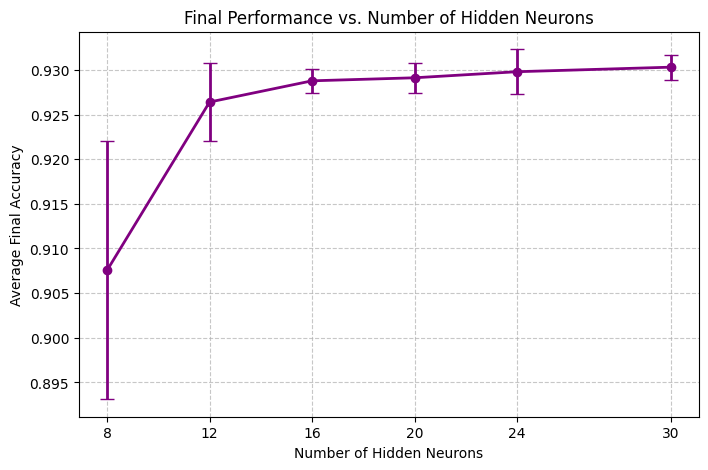

In [55]:
hidden_sizes = [8, 12, 16, 20, 24, 30] 
runs_per_size = 10
epochs = 1000 
lr = 0.013

avg_performances = []
std_performances = []

for hidden_neurons in hidden_sizes:
    print(f"Testing architecture with {hidden_neurons} hidden neurons")
    current_size_accuracies = []
    
    for run in range(runs_per_size):
        net = Network(
            layers=[
                Linear(10, hidden_neurons, init_type="xavier"),
                ActivationRelu(), 
                Linear(hidden_neurons, 7, init_type="xavier")
            ],
            output_layer=ActivationSoftmax()
        )
        
        # Train the network
        _, _ = train_without_statistics(net, X_train, y_train, Loss, lr=lr, epochs=epochs)
        val_acc = compute_accuracy(net.forward(X_val), y_val)
        # Get the final accuracy
        final_acc = val_acc
        current_size_accuracies.append(final_acc)
        
    # Calculate the average and standard deviation for this specific hidden size
    avg_performances.append(np.mean(current_size_accuracies))
    std_performances.append(np.std(current_size_accuracies))

plt.figure(figsize=(8, 5))

plt.errorbar(hidden_sizes, avg_performances, yerr=std_performances, 
             marker='o', capsize=5, linestyle='-', color='purple', linewidth=2)

plt.title("Final Performance vs. Number of Hidden Neurons")
plt.xlabel("Number of Hidden Neurons")
plt.ylabel("Average Final Accuracy")
plt.xticks(hidden_sizes)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
# hidden_layer_sizes = [8, 14, 19, 25]
# for hidden_nodes in hidden_layer_sizes:
#     print(f"Training with {hidden_nodes} neurons per layer:")
#     net = Network(
#         layers=[
#             Linear(10, hidden_nodes), 
#             ActivationRelu(), 
#         Linear(hidden_nodes, 7)],
#     output_layer=ActivationSoftmax())
    
#     losses, accuracies = train_without_statistics(net, X_train, y_train, Loss, lr=0.01, epochs=1000)
    
#     #Plotting for each run
#     plt.figure()
#     plt.plot(losses)
#     plt.title(f"Training Loss with {hidden_nodes} neurons")
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss")
#     plt.show()
#     print(f"Final accuracy with {hidden_nodes} neurons: {accuracies[-1] * 100:.2f}%\n")

#### Question 11

As the number of hidden neurons increases from 8 to 30, the average validation accuracy increases while the variance/ standard deviation decreases. However the increasing from 8 to 12 and 16 neurons is much higher than the increasing from 16 onward. We can see that the 8-neuron architecture is severily underfitting since the model can not learn the right parameters and therefore has low accuracy (about 65%). The plateau at the end indicates that the network has reached its optimal capacity and adding more neurons does not increase the accuracy much, but makes the model more complex

#### Question 12

Based on our previous explanation, it would be wise to choose either 20 or 24 hidden neurons since from 8 to 20 neurons we can see a massive steep climb in the accuracy, while after that it flattens out. It would be wise to choose the 24-neuron architecture since accuracy after that is changing very little and the variance is very low.

Based on previous experiments we will choose a learning rate of 0.1. We will be using early stopping in order to optimize our training

In [ ]:
hidden_neurons = 24 
lr = 0.1
net = Network(
    layers=[
        Linear(10, hidden_neurons, init_type="xavier"),
        ActivationRelu(), 
        Linear(hidden_neurons, 7, init_type="xavier")
    ],
    output_layer=ActivationSoftmax()
)
epochs, training_losses = train_with_early_stopping(net, X_train, y_train, X_val, y_val, Loss, lr=lr, epochs=4000, patience=20)
print(f"Best learning rate: {lr} with {epochs} epochs")
loss, accuracy = evaluate(net, X_test, y_test, Loss)
print(f"Test Loss with {hidden_neurons} hidden neurons: {loss:.4f}")
print(f"Test Accuracy with {hidden_neurons} hidden neurons: {accuracy * 100:.2f}%")

Best learning rate: 0.1 with 1743 epochs
Test Loss with 24 hidden neurons: 0.2052
Test Accuracy with 24 hidden neurons: 93.21%


### 1.5 Evaluation

#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.6 Scikit-learn

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.7 Reflection

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

### 1.8 Pen and paper

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

### 1.9 Division of work

#### Question 22

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

</div>

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**

</div>